# IFC Export

**Stage 8**  - Build the final IFC4 BIM model from room wall clouds.

This notebook:
1. Segments each room's wall cloud into planar walls
2. Computes wall geometry (start/end points, height, thickness)
3. Merges duplicate wall faces and deduplicates shared walls between rooms
4. Detects doors on merged wall surfaces
5. Snaps wall angles to Manhattan directions and endpoints to junctions
6. Writes the result as a canonical JSON and an IFC4 file

**Input:** Room wall clouds (`.ply`) from any upstream wall-assignment stage.

**Output:** `building.json` (canonical wall/door/room data) + `model.ifc` (IFC4 file).

**Requires:** `ifcopenshell` (`pip install ifcopenshell`) for the IFC4 writer.

In [8]:
import sys, os, glob, json, logging

def _find_root():
    d = os.path.abspath('')
    while True:
        if os.path.isfile(os.path.join(d, 'pyproject.toml')):
            return d
        p = os.path.dirname(d)
        if p == d:
            return os.path.abspath('')
        d = p

PROJECT_ROOT = _find_root()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
sys.path = [p for p in sys.path if not p.endswith('/src') and not p.endswith('\\src')]
for mod in list(sys.modules):
    if mod == 'scan2bim' or mod.startswith('scan2bim.'):
        del sys.modules[mod]

logging.basicConfig(level=logging.INFO, format='%(message)s')
print('Project root:', PROJECT_ROOT)

Project root: /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM


In [9]:
import scan2bim
from scan2bim import artifacts as A

CFG = scan2bim.load_config(start=PROJECT_ROOT)
print(f'IFC project name: {CFG.ifc_project_name}')
print(f'Default wall thickness: {CFG.ifc_default_thickness}m')
print(f'Min wall length: {CFG.ifc_min_wall_length_m}m')

IFC project name: Scanned Building
Default wall thickness: 0.15m
Min wall length: 0.3m


## Select upstream wall stage

In [10]:
# Choose one:
WALL_STAGE = A.STAGE3          # geometric method
# WALL_STAGE = A.STAGE_SAM_WALLS  # pure-SAM method
# WALL_STAGE = A.STAGE5          # geometric + SAM method

wall_dir = A.load_stage_dir(CFG.out_root, WALL_STAGE)
room_clouds = sorted(glob.glob(os.path.join(wall_dir, 'room_*_walls.ply')))
print(f'Found {len(room_clouds)} room wall clouds in {WALL_STAGE}')
for p in room_clouds:
    print(f'  {os.path.basename(p)}')

Found 53 room wall clouds in stage3_walls
  room_01_walls.ply
  room_02_walls.ply
  room_03_walls.ply
  room_04_walls.ply
  room_05_walls.ply
  room_06_walls.ply
  room_07_walls.ply
  room_08_walls.ply
  room_09_walls.ply
  room_10_walls.ply
  room_11_walls.ply
  room_12_walls.ply
  room_13_walls.ply
  room_14_walls.ply
  room_15_walls.ply
  room_16_walls.ply
  room_17_walls.ply
  room_18_walls.ply
  room_19_walls.ply
  room_20_walls.ply
  room_21_walls.ply
  room_22_walls.ply
  room_23_walls.ply
  room_24_walls.ply
  room_25_walls.ply
  room_26_walls.ply
  room_27_walls.ply
  room_28_walls.ply
  room_29_walls.ply
  room_30_walls.ply
  room_31_walls.ply
  room_32_walls.ply
  room_33_walls.ply
  room_34_walls.ply
  room_35_walls.ply
  room_36_walls.ply
  room_37_walls.ply
  room_38_walls.ply
  room_39_walls.ply
  room_40_walls.ply
  room_41_walls.ply
  room_42_walls.ply
  room_43_walls.ply
  room_44_walls.ply
  room_45_walls.ply
  room_46_walls.ply
  room_47_walls.ply
  room_48_walls.pl

## Build the canonical building JSON

This step segments walls, computes geometry, merges/deduplicates, detects doors,
and produces a structured JSON with walls, doors, and room boundaries.

In [11]:
from scan2bim.ifc_export import build_building_json

out_dir = A.ensure_dir(A.stage_dir(CFG.out_root, A.STAGE_IFC))
building = build_building_json(room_clouds, CFG, out_dir=out_dir)

# Save JSON
json_path = os.path.join(out_dir, A.BUILDING_JSON)
# Strip debug data for the saved version
save_data = {k: v for k, v in building.items() if k != '_debug'}
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2)
print(f'\nSaved: {json_path}')
print(f'  Walls: {len(building["walls"])}')
print(f'  Doors: {len(building["doors"])}')
print(f'  Rooms: {len(building["rooms"])}')

Processing room_01
Vertical-surface points: 16631 / 21144 (78.7%)
Angle peaks: 2  at ['90.5', '0.5']
Walls found: 8
  8 wall segments, 2 directions
  room_01 wall 2: 1 doors detected
  room_01 wall 3: 1 doors detected
Processing room_02
Vertical-surface points: 61681 / 82338 (74.9%)
Angle peaks: 2  at ['90.5', '179.5']
Walls found: 7
  7 wall segments, 2 directions
Processing room_03
Vertical-surface points: 38417 / 47616 (80.7%)
Angle peaks: 2  at ['89.5', '179.5']
Walls found: 11
  11 wall segments, 2 directions
  room_03 wall 7: 1 doors detected
Processing room_04
Vertical-surface points: 26168 / 31362 (83.4%)
Angle peaks: 2  at ['89.5', '0.5']
Walls found: 6
  6 wall segments, 2 directions
  room_04 wall 3: 1 doors detected
Processing room_05
Vertical-surface points: 3800 / 7014 (54.2%)
Angle peaks: 2  at ['89.5', '179.5']
Walls found: 3
  3 wall segments, 2 directions
Processing room_06
Vertical-surface points: 35867 / 45235 (79.3%)
Angle peaks: 2  at ['89.5', '179.5']
Walls found


Saved: /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out/stage_ifc/building.json
  Walls: 119
  Doors: 14
  Rooms: 53


## Visualize the floor plan

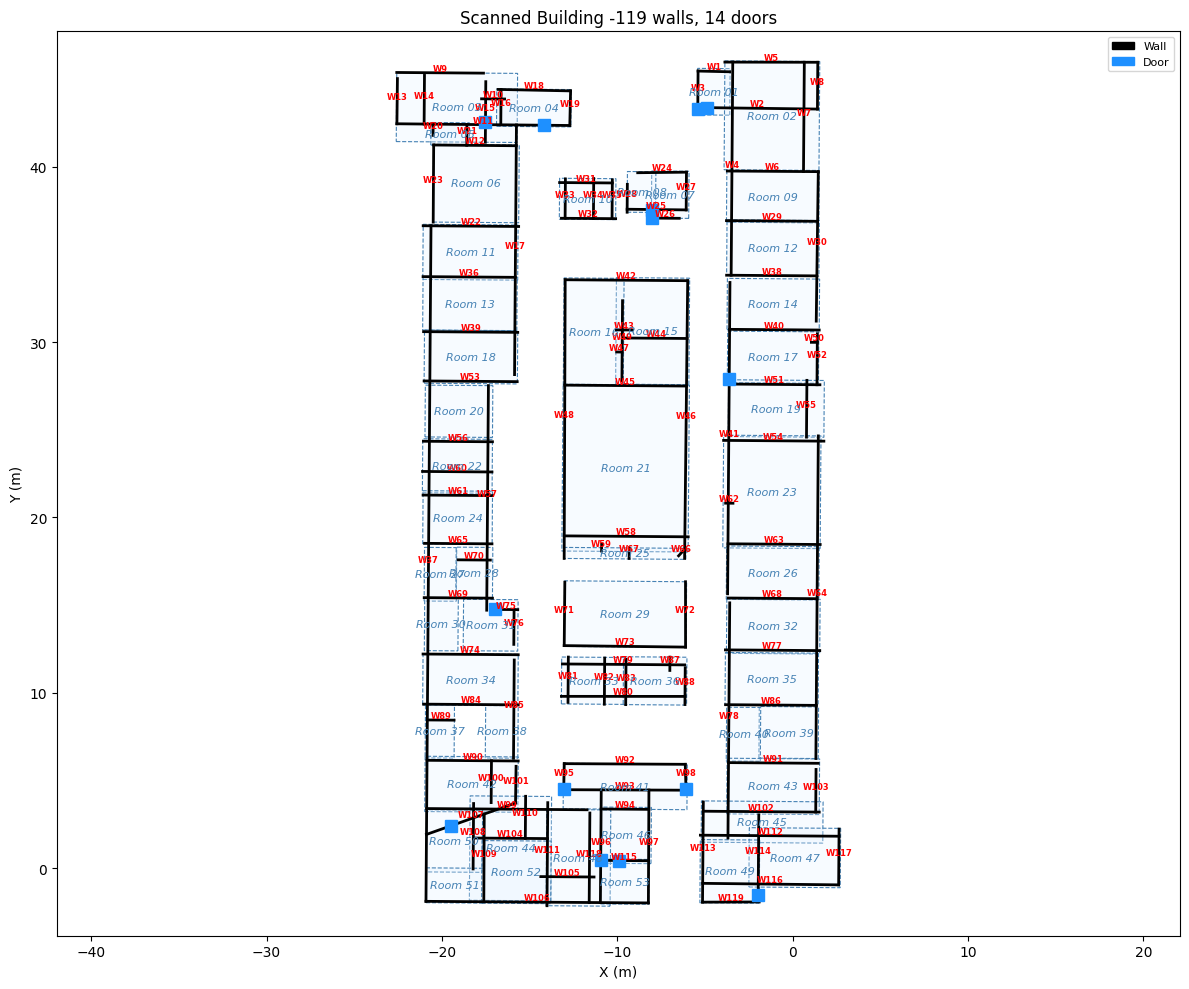

In [12]:
from scan2bim.viz import show_floor_plan

show_floor_plan(building)

## Write IFC4 file

Requires `ifcopenshell`. If not installed, skip this cell  - the building JSON above
is the canonical output and can be converted to IFC later.

In [13]:
from scan2bim.ifc_export import build_ifc

ifc_path = os.path.join(out_dir, A.IFC_MODEL)
try:
    build_ifc(building, out_path=ifc_path, cfg=CFG)
    print(f'\nIFC model written to: {ifc_path}')
except ImportError:
    print('ifcopenshell not installed  - skipping IFC export.')
    print('Install with: pip install ifcopenshell')
    print(f'The building JSON at {json_path} is the canonical output.')

Wrote /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out/stage_ifc/model.ifc  ->  {'IfcWall': 119, 'IfcDoor': 14, 'IfcWindow': 0, 'IfcSlab': 53, 'IfcSpace': 53}



IFC model written to: /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out/stage_ifc/model.ifc


In [14]:
A.save_config(os.path.join(out_dir, A.CONFIG_JSON), CFG)
z = A.package_stage(CFG.out_root, A.STAGE_IFC)
print(f'Packaged: {z}')

Packaged: /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out/stage_ifc.zip
